# S4.0 — Zero-Structure Diagnosis for CMIP6 Spatial Relationships

Diagnostic notebook — no classifier changes, no data deletion.

**Purpose:** Survey exact-zero and near-zero prevalence across CMIP6 variable pairs,
models, and climate zones before deciding whether (and how) to separate zero-structure
from continuous relationships.

**What this does:**
1. For each variable pair × model × zone, count exact zeros and near-zeros at
   multiple ε thresholds: 0, 0.1%, 0.5%, 1% × (P95 − P05).
2. Compute four-quadrant joint proportions: p00 (both near-zero), p01 (x near-zero,
   y positive), p10 (x positive, y near-zero), p11 (both positive).
3. Tabulate by zone to see whether zeros are physically expected (no snow → prsn=0,
   no vegetation → tran=0) or potentially model artefacts.
4. Compare RAW vs TRIMMED (1st/99th percentile) to check sensitivity.

**What this does NOT do:** modify the classifier, delete zero-valued points, or
assign any classification labels.

In [11]:
from __future__ import annotations

import warnings
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'axes.edgecolor': '#30343B',
    'axes.linewidth': 0.9, 'axes.titlesize': 11,
    'axes.titleweight': 'semibold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})


def locate_case_dir() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / 'cmip_utils.py').exists() and candidate.name == 'caseA':
            return candidate
        nested = candidate / 'case' / 'caseA'
        if (nested / 'cmip_utils.py').exists():
            return nested
    raise FileNotFoundError('Could not locate case/caseA/')


CASE_DIR = locate_case_dir()
DATA_ROOT = Path('/Volumes/mimi-T9/CMIP6')

MODELS = ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
EXPERIMENTS = ['historical']
START_YEAR = 1985
END_YEAR = 2014

TRIM_LOWER = 0.01
TRIM_UPPER = 0.99

VARIABLE_PAIRS = [
    ('P',          'Q',  'P → Q'),
    ('ET',         'Q',  'ET → Q'),
    ('mrros',      'Q',  'mrros → Q'),
    ('prsn',       'Q',  'prsn → Q'),
    ('tran',       'Q',  'tran → Q'),
    ('evspsblsoi', 'Q',  'evspsblsoi → Q'),
    ('hfls',       'Q',  'hfls → Q'),
    ('hfss',       'Q',  'hfss → Q'),
    ('lai',        'Q',  'lai → Q'),
    ('tas',        'Q',  'tas → Q'),
    ('rsds',       'Q',  'rsds → Q'),
    ('mrso',       'Q',  'mrso → Q'),
    ('mrsos',      'Q',  'mrsos → Q'),
    ('rlds',       'Q',  'rlds → Q'),
    ('rlus',       'Q',  'rlus → Q'),
    ('rsus',       'Q',  'rsus → Q'),
    ('P',          'ET', 'P → ET'),
]

ZONES = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']

EPSILON_LABELS = ['exact_zero', 'eps_0.1%', 'eps_0.5%', 'eps_1.0%']
EPSILON_FRACS = [0.0, 0.001, 0.005, 0.01]

# Zone colours consistent with S3_CMIP6_koppen_proxy_zones.ipynb
ZONE_COLORS = {
    'WW': '#078C78',
    'WD': '#A85F12',
    'CW': '#73C9C2',
    'CD': '#DFC27D',
    'LI': '#5B7DA8',
    'EF': '#8B6CAF',
    'KG_unclassified': '#D1D5DB',
    'ice_status_unknown': '#9CA3AF',
}
ZONE_LABELS = {
    'WW': 'Warm–Wet', 'WD': 'Warm–Dry',
    'CW': 'Cold–Wet', 'CD': 'Cold–Dry',
    'LI': 'Land Ice',
}

# Variables with exact zeros — each plotted once on a global map
ZERO_MAP_VARS = ['Q', 'mrros', 'prsn', 'tran', 'lai', 'evspsblsoi', 'mrso', 'mrsos']
ZERO_MAP_NAMES = {
    'Q': 'Total runoff (Q)',
    'mrros': 'Surface runoff (mrros)',
    'prsn': 'Snowfall flux (prsn)',
    'tran': 'Transpiration (tran)',
    'lai': 'Leaf area index (lai)',
    'evspsblsoi': 'Bare soil evaporation (evspsblsoi)',
    'mrso': 'Total soil moisture (mrso)',
    'mrsos': 'Surface soil moisture (mrsos)',
}

print(f'Case directory: {CASE_DIR}')
print(f'Data root:      {DATA_ROOT}')
print(f'Models:         {MODELS}')
print(f'Variable pairs: {len(VARIABLE_PAIRS)}')

Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Data root:      /Volumes/mimi-T9/CMIP6
Models:         ['CESM2', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4', 'CMCC-CM2-SR5']
Variable pairs: 17


In [12]:
# --- Load zone climatology for all models ---
runs = []
skipped = []
for model in MODELS:
    for experiment in EXPERIMENTS:
        search_roots = [
            DATA_ROOT / model / experiment,
            CASE_DIR / 'data' / model / experiment,
        ]
        zone_name = f'zone_climatology_{START_YEAR}_{END_YEAR}.parquet'
        found = False
        for search_root in search_roots:
            if not search_root.exists():
                continue
            zone_paths = sorted(search_root.glob(f'*/*/land/zones/{zone_name}'))
            if zone_paths:
                zp = zone_paths[0]
                t = pd.read_parquet(zp)
                t.rename(columns={'R': 'Q'}, inplace=True)
                runs.append({'model': model, 'data': t, 'path': zp})
                print(f'{model}: {len(t)} rows from {zp.relative_to(zp.parents[5])}')
                found = True
                break
        if not found:
            skipped.append(model)
            print(f'{model}: SKIPPED (no zone climatology found)')

print(f'\nLoaded: {len(runs)}, skipped: {skipped}')

CESM2: 21013 rows from historical/r1i1p1f1/gn/land/zones/zone_climatology_1985_2014.parquet
CNRM-CM6-1: 13639 rows from historical/r1i1p1f2/gr/land/zones/zone_climatology_1985_2014.parquet
CanESM5: 3464 rows from historical/r1i1p1f1/gn/land/zones/zone_climatology_1985_2014.parquet
GFDL-CM4: 22514 rows from historical/r1i1p1f1/gr1/land/zones/zone_climatology_1985_2014.parquet
CMCC-CM2-SR5: 20675 rows from historical/r1i1p1f1/gn/land/zones/zone_climatology_1985_2014.parquet

Loaded: 5, skipped: []


In [13]:
# --- Table 0: Per-variable exact-zero % by model × zone ---
# Rows = variable × model, columns = zones.
# All variables shown; 0.0 means no exact zeros.

ALL_VARS = [
    'P', 'ET', 'Q', 'mrros', 'prsn', 'tran', 'evspsblsoi',
    'hfls', 'hfss', 'lai', 'tas', 'rsds', 'rsus',
    'rlds', 'rlus', 'mrso', 'mrsos',
]
ZONE_COLS = ['all_land', 'WW', 'WD', 'CW', 'CD', 'LI']

var_zero_records = []
for run in runs:
    model = run['model']
    data = run['data']
    for var in ALL_VARS:
        if var not in data.columns:
            for zone in ZONE_COLS:
                var_zero_records.append({
                    'variable': var, 'model': model,
                    'zone': zone, 'N': 0, 'zero_%': np.nan,
                })
            continue
        vals = data[var].values.astype(float)
        zones = data['analysis_zone'].values
        finite = np.isfinite(vals)
        for zone in ZONE_COLS:
            if zone == 'all_land':
                mask = finite
            else:
                mask = finite & (zones == zone)
            n = mask.sum()
            if n == 0:
                var_zero_records.append({
                    'variable': var, 'model': model,
                    'zone': zone, 'N': 0, 'zero_%': np.nan,
                })
                continue
            n_zero = (vals[mask] == 0.0).sum()
            var_zero_records.append({
                'variable': var, 'model': model,
                'zone': zone, 'N': int(n),
                'zero_%': round(100 * n_zero / n, 1),
            })

df_var = pd.DataFrame(var_zero_records)

tbl = df_var.pivot_table(
    index=['variable', 'model'],
    columns='zone',
    values='zero_%',
    aggfunc='first',
).reindex(columns=ZONE_COLS)

tbl = tbl.fillna(0.0)

print(f'=== Exact-zero % per variable × model × zone ===')
print(f'({len(ALL_VARS)} variables × {len(MODELS)} models = {len(tbl)} rows)\n')
with pd.option_context('display.max_rows', 100):
    display(tbl)

=== Exact-zero % per variable × model × zone ===
(17 variables × 5 models = 85 rows)



zone                     all_land    WW    WD    CW   CD     LI
variable   model                                               
ET         CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.0   0.0   0.0   0.0  0.0    0.0
           GFDL-CM4           0.0   0.0   0.0   0.0  0.0    0.0
P          CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.0   0.0   0.0   0.0  0.0    0.0
           GFDL-CM4           0.0   0.0   0.0   0.0  0.0    0.0
Q          CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.6   0.0   3.0   0.0  0.0    0.0
           GFDL-CM4          27.3   0.0   0.2   0.0  0.0   84.2
evspsblsoi CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1        28.5   7.6   0.2   0.0  0.0   81.0
           CanESM5            0.0   0.0   0.0   0.0  0.0    0.0
           GFDL-CM4          27.2   0.0   0.0   0.0  0.0   84.3
hfls       CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.0   0.0   0.0   0.0  0.0    0.0
           GFDL-CM4           0.0   0.0   0.0   0.0  0.0    0.0
hfss       CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.0   0.0   0.0   0.0  0.0    0.0
           GFDL-CM4           0.0   0.0   0.0   0.0  0.0    0.0
lai        CESM2             39.3   0.0   6.8  21.9  1.2   93.2
           CMCC-CM2-SR5      37.2   0.0  11.3   8.1  2.4   93.2
           CNRM-CM6-1        30.9   0.0  12.9   0.2  0.0   83.7
           CanESM5           32.7   0.0   5.4   0.0  0.0  100.0
           GFDL-CM4          27.5   0.0   0.9   0.0  0.3   84.4
mrros      CESM2             28.7   0.0   0.1   0.0  0.5   80.7
           CMCC-CM2-SR5      29.0   0.0   0.0   0.0  0.0   81.6
           CNRM-CM6-1        26.5   0.0   0.0   0.0  0.0   78.3
           CanESM5           25.6   0.0   3.2   0.0  0.0   78.9
           GFDL-CM4          27.4   0.0   1.0   0.0  0.0   84.2
mrso       CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5      27.5   0.0   0.0   0.0  0.0   77.2
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.3   0.0   0.0   0.0  0.0    1.1
           GFDL-CM4          27.2   0.0   0.0   0.0  0.0   84.2
mrsos      CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.3   0.0   0.0   0.0  0.0    1.1
           GFDL-CM4          27.2   0.0   0.0   0.0  0.0   84.2
prsn       CESM2             21.8  56.6  74.6   0.0  2.4    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5           22.8  57.6  70.8   0.2  3.2    0.0
           GFDL-CM4          20.4  52.6  66.5   0.0  0.5    0.0
rlds       CESM2              0.0   0.0   0.0   0.0  0.0    0.0
           CMCC-CM2-SR5       0.0   0.0   0.0   0.0  0.0    0.0
           CNRM-CM6-1         0.0   0.0   0.0   0.0  0.0    0.0
           CanESM5            0.0   0.0   0.0   0.0  0.0    0.0
           GFDL-CM4           0.0   0.0   0.0   0.0  0.0    0.0
rlus       CESM2              0.

In [14]:
# --- Compute epsilon thresholds per variable per model ---
# epsilon = frac * (P95 - P05) of the variable, computed on the full dataset


def compute_eps(series: pd.Series, frac: float) -> float:
    """Compute near-zero threshold as frac * (P95 - P05)."""
    if frac == 0.0:
        return 0.0
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    return frac * (p95 - p05)


def is_near_zero(values: np.ndarray, eps: float) -> np.ndarray:
    """Boolean mask for values within eps of zero."""
    if eps == 0.0:
        return values == 0.0
    return np.abs(values) <= eps


def filter_zone(data: pd.DataFrame, zone: str) -> pd.DataFrame:
    if zone == 'all_land':
        return data
    return data[data['analysis_zone'] == zone]


def trim_pair(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (mask, x_trimmed, y_trimmed) after removing lower/upper quantiles."""
    mask = np.ones(len(x), dtype=bool)
    for arr in [x, y]:
        lo = np.nanquantile(arr, TRIM_LOWER)
        hi = np.nanquantile(arr, TRIM_UPPER)
        mask &= (arr >= lo) & (arr <= hi)
    return mask, x[mask], y[mask]


print('Helper functions defined.')

Helper functions defined.


In [15]:
# --- Main diagnostic loop ---
# For each model × variable pair × zone × epsilon × raw/trimmed:
#   compute marginal zero fractions and four-quadrant proportions.

records = []

for run in runs:
    model = run['model']
    data = run['data']

    for x_var, y_var, pair_label in VARIABLE_PAIRS:
        if x_var not in data.columns or y_var not in data.columns:
            continue

        for zone in ZONES:
            sub = filter_zone(data, zone)
            if len(sub) < 20:
                continue

            x_raw = sub[x_var].values.astype(float)
            y_raw = sub[y_var].values.astype(float)
            finite = np.isfinite(x_raw) & np.isfinite(y_raw)
            x_raw, y_raw = x_raw[finite], y_raw[finite]
            if len(x_raw) < 20:
                continue

            trim_mask, x_trim, y_trim = trim_pair(x_raw, y_raw)

            for stage, x_arr, y_arr in [('RAW', x_raw, y_raw), ('TRIMMED', x_trim, y_trim)]:
                n = len(x_arr)
                if n < 20:
                    continue

                for eps_label, eps_frac in zip(EPSILON_LABELS, EPSILON_FRACS):
                    eps_x = compute_eps(pd.Series(x_arr), eps_frac)
                    eps_y = compute_eps(pd.Series(y_arr), eps_frac)

                    xz = is_near_zero(x_arr, eps_x)
                    yz = is_near_zero(y_arr, eps_y)

                    p00 = (xz & yz).sum()
                    p01 = (xz & ~yz).sum()
                    p10 = (~xz & yz).sum()
                    p11 = (~xz & ~yz).sum()

                    records.append({
                        'model': model,
                        'pair': pair_label,
                        'x_var': x_var,
                        'y_var': y_var,
                        'zone': zone,
                        'stage': stage,
                        'eps_level': eps_label,
                        'eps_x': eps_x,
                        'eps_y': eps_y,
                        'n_total': n,
                        'n_x_zero': xz.sum(),
                        'n_y_zero': yz.sum(),
                        'pct_x_zero': 100 * xz.sum() / n,
                        'pct_y_zero': 100 * yz.sum() / n,
                        'p00': p00,
                        'p01': p01,
                        'p10': p10,
                        'p11': p11,
                        'frac_p00': p00 / n,
                        'frac_p01': p01 / n,
                        'frac_p10': p10 / n,
                        'frac_p11': p11 / n,
                    })

df = pd.DataFrame(records)
print(f'Total diagnostic records: {len(df)}')
print(f'Models: {sorted(df["model"].unique())}')
print(f'Pairs:  {sorted(df["pair"].unique())}')
print(f'Zones:  {sorted(df["zone"].unique())}')

Total diagnostic records: 4080
Models: ['CESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5', 'GFDL-CM4']
Pairs:  ['ET → Q', 'P → ET', 'P → Q', 'evspsblsoi → Q', 'hfls → Q', 'hfss → Q', 'lai → Q', 'mrros → Q', 'mrso → Q', 'mrsos → Q', 'prsn → Q', 'rlds → Q', 'rlus → Q', 'rsds → Q', 'rsus → Q', 'tas → Q', 'tran → Q']
Zones:  ['CD', 'CW', 'LI', 'WD', 'WW', 'all_land']


In [16]:
# --- Table 3: Epsilon sensitivity (all_land, RAW, CESM2) ---
# Does the near-zero fraction change substantially with epsilon?
# If it jumps a lot, the zero boundary is fuzzy (rounding / noise).
# If it stays stable, zeros are true point-mass at 0.

cesm2_allland_raw = df[
    (df['model'] == 'CESM2')
    & (df['zone'] == 'all_land')
    & (df['stage'] == 'RAW')
].copy()

# Only pairs where exact zeros exist
pairs_with_zeros = cesm2_allland_raw[
    (cesm2_allland_raw['eps_level'] == 'exact_zero')
    & ((cesm2_allland_raw['pct_x_zero'] > 0) | (cesm2_allland_raw['pct_y_zero'] > 0))
]['pair'].unique()

for pair in sorted(pairs_with_zeros):
    sub = cesm2_allland_raw[cesm2_allland_raw['pair'] == pair][
        ['eps_level', 'eps_x', 'eps_y', 'pct_x_zero', 'pct_y_zero']
    ].copy()
    sub = sub.set_index('eps_level').reindex(EPSILON_LABELS)
    sub.columns = ['ε_x', 'ε_y', 'x_near_zero_%', 'y_near_zero_%']
    print(f'\n--- {pair} (CESM2, all_land, RAW) ---')
    display(sub.round(3))


--- lai → Q (CESM2, all_land, RAW) ---


,ε_x,ε_y,x_near_zero_%,y_near_zero_%
eps_level,,,,
exact_zero,0.000,0.000,39.295,0.000
eps_0.1%,0.004,1.070,42.916,25.665
eps_0.5%,0.022,5.352,44.430,30.296
eps_1.0%,0.044,10.704,45.348,33.208



--- mrros → Q (CESM2, all_land, RAW) ---


,ε_x,ε_y,x_near_zero_%,y_near_zero_%
eps_level,,,,
exact_zero,0.000,0.000,28.663,0.000
eps_0.1%,0.426,1.070,31.285,25.665
eps_0.5%,2.132,5.352,32.599,30.296
eps_1.0%,4.263,10.704,34.778,33.208



--- prsn → Q (CESM2, all_land, RAW) ---


,ε_x,ε_y,x_near_zero_%,y_near_zero_%
eps_level,,,,
exact_zero,0.000,0.000,21.825,0.000
eps_0.1%,0.480,1.070,27.569,25.665
eps_0.5%,2.400,5.352,28.725,30.296
eps_1.0%,4.799,10.704,29.415,33.208



--- tran → Q (CESM2, all_land, RAW) ---


,ε_x,ε_y,x_near_zero_%,y_near_zero_%
eps_level,,,,
exact_zero,0.000,0.000,33.108,0.000
eps_0.1%,0.658,1.070,42.597,25.665
eps_0.5%,3.292,5.352,43.992,30.296
eps_1.0%,6.584,10.704,44.891,33.208


In [17]:
# --- Table 4: Four-quadrant proportions for high-zero pairs ---
# Focus on pairs × zones where at least one arm has >15% exact zeros.
# This shows whether zeros cluster on one axis or both.

high_zero = df[
    (df['eps_level'] == 'exact_zero')
    & (df['stage'] == 'RAW')
    & ((df['pct_x_zero'] > 15) | (df['pct_y_zero'] > 15))
].copy()

if len(high_zero) > 0:
    quad_table = high_zero[[
        'model', 'pair', 'zone', 'n_total',
        'frac_p00', 'frac_p01', 'frac_p10', 'frac_p11',
    ]].copy()
    for col in ['frac_p00', 'frac_p01', 'frac_p10', 'frac_p11']:
        quad_table[col] = (quad_table[col] * 100).round(1)
    quad_table.columns = [
        'Model', 'Pair', 'Zone', 'N',
        'both_zero_%', 'x0_y+_%', 'x+_y0_%', 'both_pos_%',
    ]
    quad_table = quad_table.sort_values(['Pair', 'Model', 'Zone'])
    display(quad_table.reset_index(drop=True))
else:
    print('No pairs with >15% zero on either axis.')

,Model,Pair,Zone,N,both_zero_%,x0_y+_%,x+_y0_%,both_pos_%
0,GFDL-CM4,ET → Q,LI,7273,0.0,0.0,84.2,15.8
1,GFDL-CM4,ET → Q,all_land,22514,0.0,0.0,27.3,72.7
2,GFDL-CM4,P → Q,LI,7273,0.0,0.0,84.2,15.8
3,GFDL-CM4,P → Q,all_land,22514,0.0,0.0,27.3,72.7
4,CNRM-CM6-1,evspsblsoi → Q,LI,4610,0.0,81.0,0.0,19.0
...,...,...,...,...,...,...,...,...
64,CNRM-CM6-1,tran → Q,all_land,13639,0.0,30.9,0.0,69.1
65,CanESM5,tran → Q,LI,1095,0.0,100.0,0.0,0.0
66,CanESM5,tran → Q,all_land,3464,0.6,32.2,0.0,67.2
67,GFDL-CM4,tran → Q,LI,7273,84.2,0.2,0.0,15.6


In [18]:
# --- Table 5: RAW vs TRIMMED comparison ---
# Does trimming change the zero picture?

compare = df[
    (df['eps_level'] == 'exact_zero')
    & (df['zone'] == 'all_land')
    & (df['model'] == 'CESM2')
].copy()

compare_pivot = compare.pivot_table(
    index='pair',
    columns='stage',
    values=['pct_x_zero', 'pct_y_zero', 'n_total'],
    aggfunc='first',
)
compare_pivot.columns = [f'{v}_{s}' for v, s in compare_pivot.columns]
compare_pivot = compare_pivot[[
    'n_total_RAW', 'n_total_TRIMMED',
    'pct_x_zero_RAW', 'pct_x_zero_TRIMMED',
    'pct_y_zero_RAW', 'pct_y_zero_TRIMMED',
]].round(1)

print('=== RAW vs TRIMMED exact-zero % (CESM2, all_land) ===')
display(compare_pivot)

=== RAW vs TRIMMED exact-zero % (CESM2, all_land) ===


,n_total_RAW,n_total_TRIMMED,pct_x_zero_RAW,pct_x_zero_TRIMMED,pct_y_zero_RAW,pct_y_zero_TRIMMED
pair,,,,,,
ET → Q,21013,20180,0.0,0.0,0.0,0.0
P → ET,21013,20172,0.0,0.0,0.0,0.0
P → Q,21013,20335,0.0,0.0,0.0,0.0
evspsblsoi → Q,21013,20237,0.0,0.0,0.0,0.0
hfls → Q,21013,20180,0.0,0.0,0.0,0.0
hfss → Q,21013,20170,0.0,0.0,0.0,0.0
lai → Q,21013,20446,39.3,40.2,0.0,0.0
mrros → Q,21013,20491,28.7,29.2,0.0,0.0
mrso → Q,15277,14679,0.0,0.0,0.0,0.0


In [19]:
# --- Summary: classify zero-structure type per pair × model × zone ---
# Based on exact-zero, RAW data.
# Categories:
#   None           — neither axis has >5% exact zeros
#   X-zero arm     — x has >15% exact zeros, y does not
#   Y-zero arm     — y has >15% exact zeros, x does not
#   Double-zero    — both axes have >15% exact zeros
#   Minor x-zero   — x has 5-15% exact zeros
#   Minor y-zero   — y has 5-15% exact zeros

THR_MAJOR = 15.0
THR_MINOR = 5.0

exact_all = df[
    (df['eps_level'] == 'exact_zero')
    & (df['stage'] == 'RAW')
].copy()


def classify_zero_structure(row):
    xz = row['pct_x_zero']
    yz = row['pct_y_zero']
    if xz >= THR_MAJOR and yz >= THR_MAJOR:
        return 'Double-zero'
    if xz >= THR_MAJOR:
        return 'X-zero arm'
    if yz >= THR_MAJOR:
        return 'Y-zero arm'
    if xz >= THR_MINOR:
        return 'Minor x-zero'
    if yz >= THR_MINOR:
        return 'Minor y-zero'
    return 'None'


exact_all['zero_structure'] = exact_all.apply(classify_zero_structure, axis=1)

summary = exact_all.pivot_table(
    index=['pair', 'zone'],
    columns='model',
    values='zero_structure',
    aggfunc='first',
)

# Show only rows where at least one model has a non-None structure
has_structure = summary[
    summary.apply(lambda row: any(v != 'None' for v in row if pd.notna(v)), axis=1)
]

print(f'=== Zero-structure classification (exact zero, RAW) ===')
print(f'Rows with at least one non-None structure: {len(has_structure)}')
print()
display(has_structure)

=== Zero-structure classification (exact zero, RAW) ===
Rows with at least one non-None structure: 39



model                           CESM2  CMCC-CM2-SR5    CNRM-CM6-1  \
pair           zone                                                 
ET → Q         LI                None          None          None   
               all_land          None          None          None   
P → Q          LI                None          None          None   
               all_land          None          None          None   
evspsblsoi → Q LI                None          None    X-zero arm   
               WW                None          None  Minor x-zero   
               all_land          None          None    X-zero arm   
hfls → Q       LI                None          None          None   
               all_land          None          None          None   
hfss → Q       LI                None          None          None   
               all_land          None          None          None   
lai → Q        CW          X-zero arm  Minor x-zero          None   
               LI          X-zero arm    X-zero arm    X-zero arm   
               WD        Minor x-zero  Minor x-zero  Minor x-zero   
               all_land    X-zero arm    X-zero arm    X-zero arm   
mrros → Q      LI          X-zero arm    X-zero arm    X-zero arm   
               all_land    X-zero arm    X-zero arm    X-zero arm   
mrso → Q       LI                None    X-zero arm          None   
               all_land          None    X-zero arm          None   
mrsos → Q      LI                None          None          None   
               all_land          None          None          None   
prsn → Q       LI                None          None          None   
               WD          X-zero arm          None          None   
               WW          X-zero arm          None          None   
               all_land    X-zero arm          None          None   
rlds → Q       LI                None          None          None   
               all_land          None          None          None   
rlus → Q       LI                None          None          None   
               all_land          None          None          None   
rsds → Q       LI                None          None          None   
               all_land          None          None          None   
rsus → Q       LI                None          None          None   
               all_land          None          None          None   
tas → Q        LI                None          None          None   
               all_land          None          None          None   
tran → Q       CW                None  Minor x-zero          None   
               LI          X-zero arm    X-zero arm    X-zero arm   
               WD                None  Minor x-zero  Minor x-zero   
               all_land    X-zero arm    X-zero arm    X-zero arm   

model                         CanESM5     GFDL-CM4  
pair           zone                                 
ET → Q         LI                None   Y-zero arm  
               all_land          None   Y-zero arm  
P → Q          LI                None   Y-zero arm  
               all_land          None   Y-zero arm  
evspsblsoi → Q LI                None  Double-zero  
               WW                None         None  
               all_land          None  Double-zero  
hfls → Q       LI                None   Y-zero arm  
               all_land          None   Y-zero arm  
hfss → Q       LI                None   Y-zero arm  
               all_land          None   Y-zero arm  
lai → Q        CW                None         None  
               LI          X-zero arm  Double-zero  
               WD        Minor x-zero         None  
               all_land    X-zero arm  Double-zero  
mrros → Q      LI          X-zero arm  Double-zero  
               all_land    X-zero arm  Double-zero  
mrso → Q       LI                None  Double-zero  
               all_land          None  Double-zero  
mrsos → Q      LI                None  Double-zero  
    

In [20]:
# --- GFDL-CM4 zero-mask overlap verification ---
# Check whether Q=0, mrso=0, mrsos=0, evspsblsoi=0, lai=0, tran=0, mrros=0
# fall on the exact same set of grid cells in GFDL-CM4.

gfdl_run = [r for r in runs if r['model'] == 'GFDL-CM4'][0]
gfdl = gfdl_run['data']

zero_vars = ['Q', 'mrros', 'tran', 'lai', 'evspsblsoi', 'mrso', 'mrsos']
zero_vars_available = [v for v in zero_vars if v in gfdl.columns]

zero_masks = {}
for v in zero_vars_available:
    vals = gfdl[v].values.astype(float)
    zero_masks[v] = (vals == 0.0) & np.isfinite(vals)

n_grid = len(gfdl)
print(f'GFDL-CM4: {n_grid} grid cells total\n')

# Pairwise overlap (Jaccard similarity)
print('=== Pairwise zero-mask overlap (Jaccard = intersection/union) ===\n')
overlap_records = []
for i, v1 in enumerate(zero_vars_available):
    for v2 in zero_vars_available[i+1:]:
        m1, m2 = zero_masks[v1], zero_masks[v2]
        intersect = (m1 & m2).sum()
        union = (m1 | m2).sum()
        jaccard = intersect / union if union > 0 else 0
        overlap_records.append({
            'var_1': v1, 'var_2': v2,
            'n_1': m1.sum(), 'n_2': m2.sum(),
            'intersection': intersect, 'union': union,
            'jaccard': round(jaccard, 4),
        })

df_overlap = pd.DataFrame(overlap_records)
display(df_overlap)

# Check: are all zero masks subsets of each other?
print('\n=== Union of all zero masks ===')
all_union = np.zeros(n_grid, dtype=bool)
all_intersect = np.ones(n_grid, dtype=bool)
for v in zero_vars_available:
    all_union |= zero_masks[v]
    all_intersect &= zero_masks[v]

print(f'Any variable =0:  {all_union.sum()} grid cells ({100*all_union.sum()/n_grid:.1f}%)')
print(f'All variables =0: {all_intersect.sum()} grid cells ({100*all_intersect.sum()/n_grid:.1f}%)')
print(f'Overlap ratio (all/any): {all_intersect.sum()/all_union.sum():.4f}')

# Zone distribution of the union mask
print('\n=== Zone distribution of GFDL zero-mask union ===')
zones = gfdl['analysis_zone'].values
for zn in ['WW', 'WD', 'CW', 'CD', 'LI']:
    zmask = zones == zn
    n_zone = zmask.sum()
    n_zero_in_zone = (all_union & zmask).sum()
    print(f'  {zn}: {n_zero_in_zone}/{n_zone} = {100*n_zero_in_zone/n_zone:.1f}%')

GFDL-CM4: 22514 grid cells total

=== Pairwise zero-mask overlap (Jaccard = intersection/union) ===



,var_1,var_2,n_1,n_2,intersection,union,jaccard
0,Q,mrros,6142,6176,6142,6176,0.9945
1,Q,tran,6142,6184,6128,6198,0.9887
2,Q,lai,6142,6184,6128,6198,0.9887
3,Q,evspsblsoi,6142,6133,6128,6147,0.9969
4,Q,mrso,6142,6128,6128,6142,0.9977
5,Q,mrsos,6142,6128,6128,6142,0.9977
6,mrros,tran,6176,6184,6150,6210,0.9903
7,mrros,lai,6176,6184,6150,6210,0.9903
8,mrros,evspsblsoi,6176,6133,6128,6181,0.9914
9,mrros,mrso,6176,6128,6128,6176,0.9922



=== Union of all zero masks ===
Any variable =0:  6210 grid cells (27.6%)
All variables =0: 6128 grid cells (27.2%)
Overlap ratio (all/any): 0.9868

=== Zone distribution of GFDL zero-mask union ===
  WW: 0/2653 = 0.0%
  WD: 57/4162 = 1.4%
  CW: 1/4714 = 0.0%
  CD: 7/2272 = 0.3%
  LI: 6138/7273 = 84.4%


In [21]:
# --- Attribution summary: two-tier zero-value classification ---

attribution_rows = [
    {
        'Zero type': 'Physically interpretable zeros',
        'Variables': 'lai, tran, prsn, mrros*',
        'Observed pattern': (
            'Zeros occur where the corresponding process is weak or absent '
            'and show broadly consistent spatial patterns across models'
        ),
        'Interpretation': (
            'Absence of vegetation, transpiration, snowfall, '
            'or diagnosed surface runoff'
        ),
    },
    {
        'Zero type': 'Physically uncertain zeros',
        'Variables': 'Q (GFDL), mrso (GFDL & CMCC), mrsos (GFDL), evspsblsoi (GFDL & CNRM)',
        'Observed pattern': (
            'Large exact-zero fractions occur only in one or a subset of models, '
            'mainly over Land Ice'
        ),
        'Interpretation': (
            'Likely reflects model-specific treatment of land-ice grid cells '
            'and cannot be interpreted directly as process absence'
        ),
    },
]

df_attr = pd.DataFrame(attribution_rows)

print('=== Zero-Value Attribution Summary ===\n')
print('Type 1 — Physically interpretable zeros')
print('  Variables:   lai, tran, prsn, mrros*')
print('  Pattern:     Zeros where the process is weak/absent; consistent across models')
print('  Meaning:     No vegetation, no transpiration, no snowfall, no surface runoff')
print()
print('Type 2 — Physically uncertain zeros')
print('  Variables:   Q (GFDL), mrso (GFDL & CMCC), mrsos (GFDL), evspsblsoi (GFDL & CNRM)')
print('  Pattern:     Large exact-zero fractions in only 1–2 models, mainly over Land Ice')
print('  Meaning:     Model-specific ice-cell treatment; cannot assume process absence')
print()
print('* mrros has ~26–29% zeros in all 5 models (mainly LI), so spatial evidence')
print('  is consistent. However, "no surface runoff on ice" still depends on how')
print('  each model defines meltwater routing, so it is listed with a caveat.')
print()

display(df_attr)

=== Zero-Value Attribution Summary ===

Type 1 — Physically interpretable zeros
  Variables:   lai, tran, prsn, mrros*
  Pattern:     Zeros where the process is weak/absent; consistent across models
  Meaning:     No vegetation, no transpiration, no snowfall, no surface runoff

Type 2 — Physically uncertain zeros
  Variables:   Q (GFDL), mrso (GFDL & CMCC), mrsos (GFDL), evspsblsoi (GFDL & CNRM)
  Pattern:     Large exact-zero fractions in only 1–2 models, mainly over Land Ice
  Meaning:     Model-specific ice-cell treatment; cannot assume process absence

* mrros has ~26–29% zeros in all 5 models (mainly LI), so spatial evidence
  is consistent. However, "no surface runoff on ice" still depends on how
  each model defines meltwater routing, so it is listed with a caveat.



,Zero type,Variables,Observed pattern,Interpretation
0,Physically interpretable zeros,"lai, tran, prsn, mrros*",Zeros occur where the corresponding process is...,"Absence of vegetation, transpiration, snowfall..."
1,Physically uncertain zeros,"Q (GFDL), mrso (GFDL & CMCC), mrsos (GFDL), ev...",Large exact-zero fractions occur only in one o...,Likely reflects model-specific treatment of la...


In [22]:
# --- A/B impact analysis: exact-zero separation ---
# For each pair × model × zone, separate exact zeros into four groups:
#   Both-zero  (x=0, y=0)   → p00
#   X-zero     (x=0, y≠0)   → p01
#   Y-zero     (x≠0, y=0)   → p10
#   Continuous (x≠0, y≠0)   → p11
#
# Status:
#   Unchanged                  — no exact zeros on either axis
#   Zero-dominated             — N_cont < MIN_CONT (not enough to classify)
#   May change                 — has zeros but enough continuous data remains

MIN_CONT = 30

exact_raw = df[
    (df['eps_level'] == 'exact_zero')
    & (df['stage'] == 'RAW')
].copy()

exact_raw['N_cont'] = exact_raw['p11'].astype(int)
exact_raw['retention'] = exact_raw['p11'] / exact_raw['n_total']


def ab_status(row):
    n_zero = row['p00'] + row['p01'] + row['p10']
    if n_zero == 0:
        return 'Unchanged'
    if row['N_cont'] < MIN_CONT:
        return 'Zero-dominated'
    return 'May change'


exact_raw['status'] = exact_raw.apply(ab_status, axis=1)

# --- Summary counts ---
print('=== A/B Impact: Exact-Zero Separation ===\n')
status_order = ['Unchanged', 'May change', 'Zero-dominated']
status_counts = exact_raw['status'].value_counts()
print('Panel status summary:')
for s in status_order:
    print(f'  {s}: {status_counts.get(s, 0)}')
print(f'  Total panels: {len(exact_raw)}\n')

# --- Affected panels ---
affected = exact_raw[exact_raw['status'] != 'Unchanged'].copy()
affected = affected.sort_values(['pair', 'model', 'zone'])

cols_show = [
    'model', 'pair', 'zone', 'n_total',
    'p00', 'p01', 'p10', 'N_cont', 'retention', 'status',
]
disp = affected[cols_show].copy()
disp['retention'] = (disp['retention'] * 100).round(1).astype(str) + '%'
disp.columns = [
    'Model', 'Pair', 'Zone', 'N_all',
    'p00', 'p01', 'p10', 'N_cont', 'Retention', 'Status',
]

print(f'Panels affected by zero separation: {len(disp)}\n')
with pd.option_context('display.max_rows', 200, 'display.max_columns', 12):
    display(disp.reset_index(drop=True))

# --- Zone breakdown ---
print('\n=== Zone breakdown of affected panels ===')
zone_status = (
    affected.groupby(['zone', 'status']).size()
    .unstack(fill_value=0)
    .reindex(columns=[s for s in status_order if s != 'Unchanged'], fill_value=0)
)
display(zone_status)

# --- Model breakdown ---
print('\n=== Model breakdown of affected panels ===')
model_status = (
    affected.groupby(['model', 'status']).size()
    .unstack(fill_value=0)
    .reindex(columns=[s for s in status_order if s != 'Unchanged'], fill_value=0)
)
display(model_status)

# --- Pairs fully unaffected ---
pair_all = exact_raw.groupby('pair')['status'].apply(
    lambda s: all(v == 'Unchanged' for v in s)
)
never_change = sorted(pair_all[pair_all].index)
print(f'\nPairs fully unaffected ({len(never_change)}): {", ".join(never_change)}')

=== A/B Impact: Exact-Zero Separation ===

Panel status summary:
  Unchanged: 350
  May change: 158
  Zero-dominated: 2
  Total panels: 510

Panels affected by zero separation: 160



,Model,Pair,Zone,N_all,p00,p01,p10,N_cont,Retention,Status
0,CanESM5,ET → Q,WD,710,0,0,21,689,97.0%,May change
1,CanESM5,ET → Q,all_land,3464,0,0,21,3443,99.4%,May change
2,GFDL-CM4,ET → Q,CD,2272,0,0,1,2271,100.0%,May change
3,GFDL-CM4,ET → Q,LI,7273,0,0,6127,1146,15.8%,May change
4,GFDL-CM4,ET → Q,WD,4162,0,0,9,4153,99.8%,May change
5,GFDL-CM4,ET → Q,all_land,22514,0,0,6142,16372,72.7%,May change
6,CanESM5,P → Q,WD,710,0,0,21,689,97.0%,May change
7,CanESM5,P → Q,all_land,3464,0,0,21,3443,99.4%,May change
8,GFDL-CM4,P → Q,CD,2272,0,0,1,2271,100.0%,May change
9,GFDL-CM4,P → Q,LI,7273,0,0,6127,1146,15.8%,May change



=== Zone breakdown of affected panels ===


status,May change,Zero-dominated
zone,,
CD,23,0
CW,12,0
LI,31,2
WD,41,0
WW,7,0
all_land,44,0



=== Model breakdown of affected panels ===


status,May change,Zero-dominated
model,,
CESM2,21,0
CMCC-CM2-SR5,18,0
CNRM-CM6-1,14,0
CanESM5,39,2
GFDL-CM4,66,0



Pairs fully unaffected (1): P → ET


## Global maps: exact-zero spatial distribution

One figure per variable, five sub-panels (one per model). Each map shows:
- **Zone background** — climate zone colour (WW/WD/CW/CD/LI) from S3
- **Light grey** — grid cells with non-zero values (overpaints zone colour)
- **Red** — grid cells with exact zero (top layer, most visible)

This reveals whether zeros are geographically coherent and physically expected
(e.g. prsn=0 in warm regions, tran=0 on ice sheets) or scattered/artefactual.

Only exact zeros (ε=0) are shown. Near-zero maps can be added separately.

Saved: zero_map_Q.png


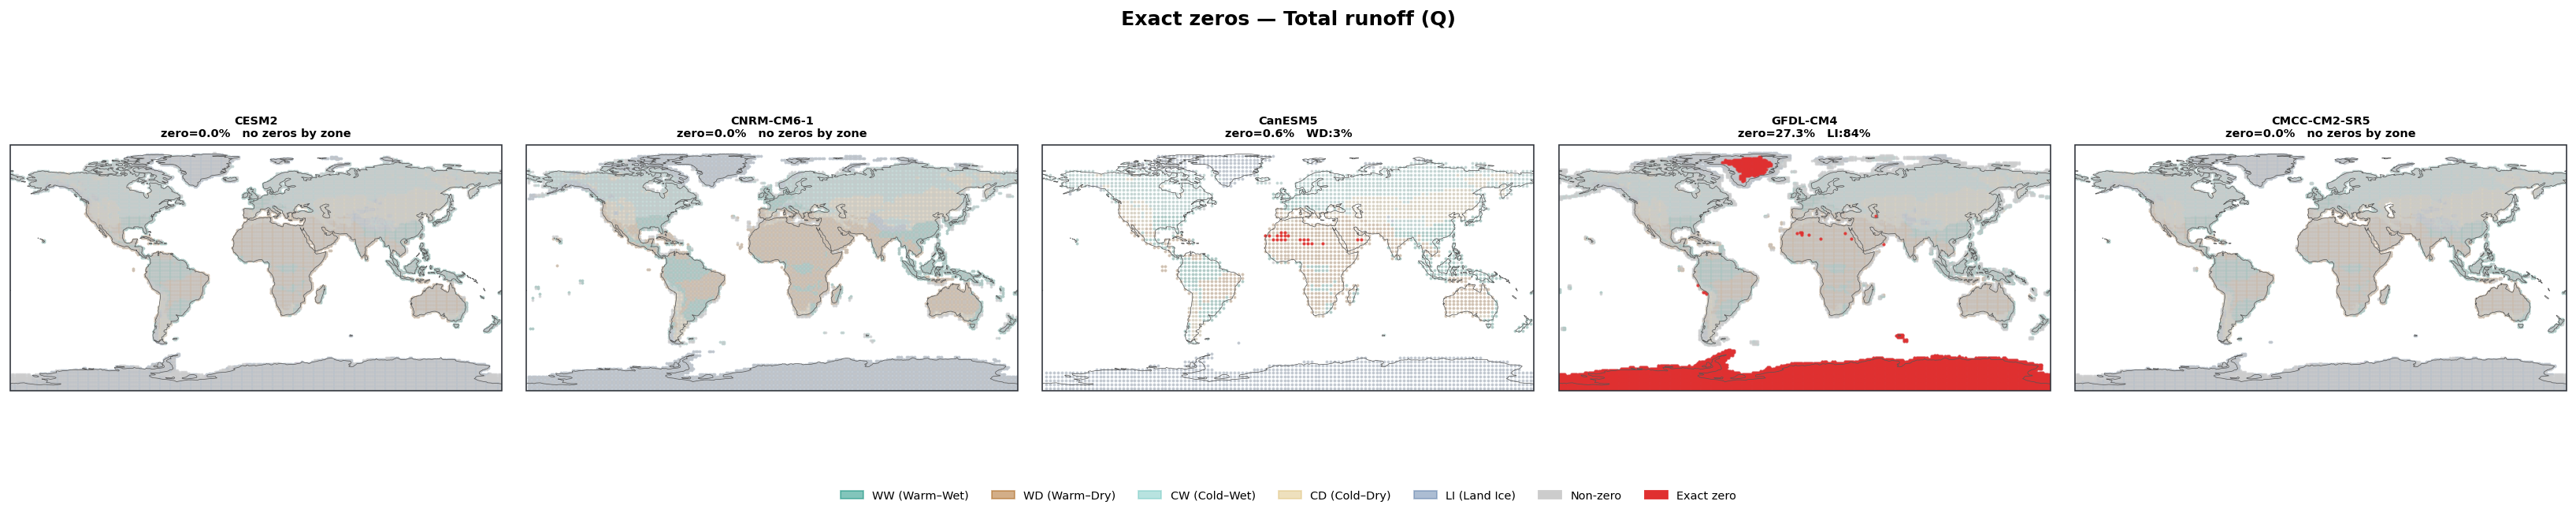

Saved: zero_map_mrros.png


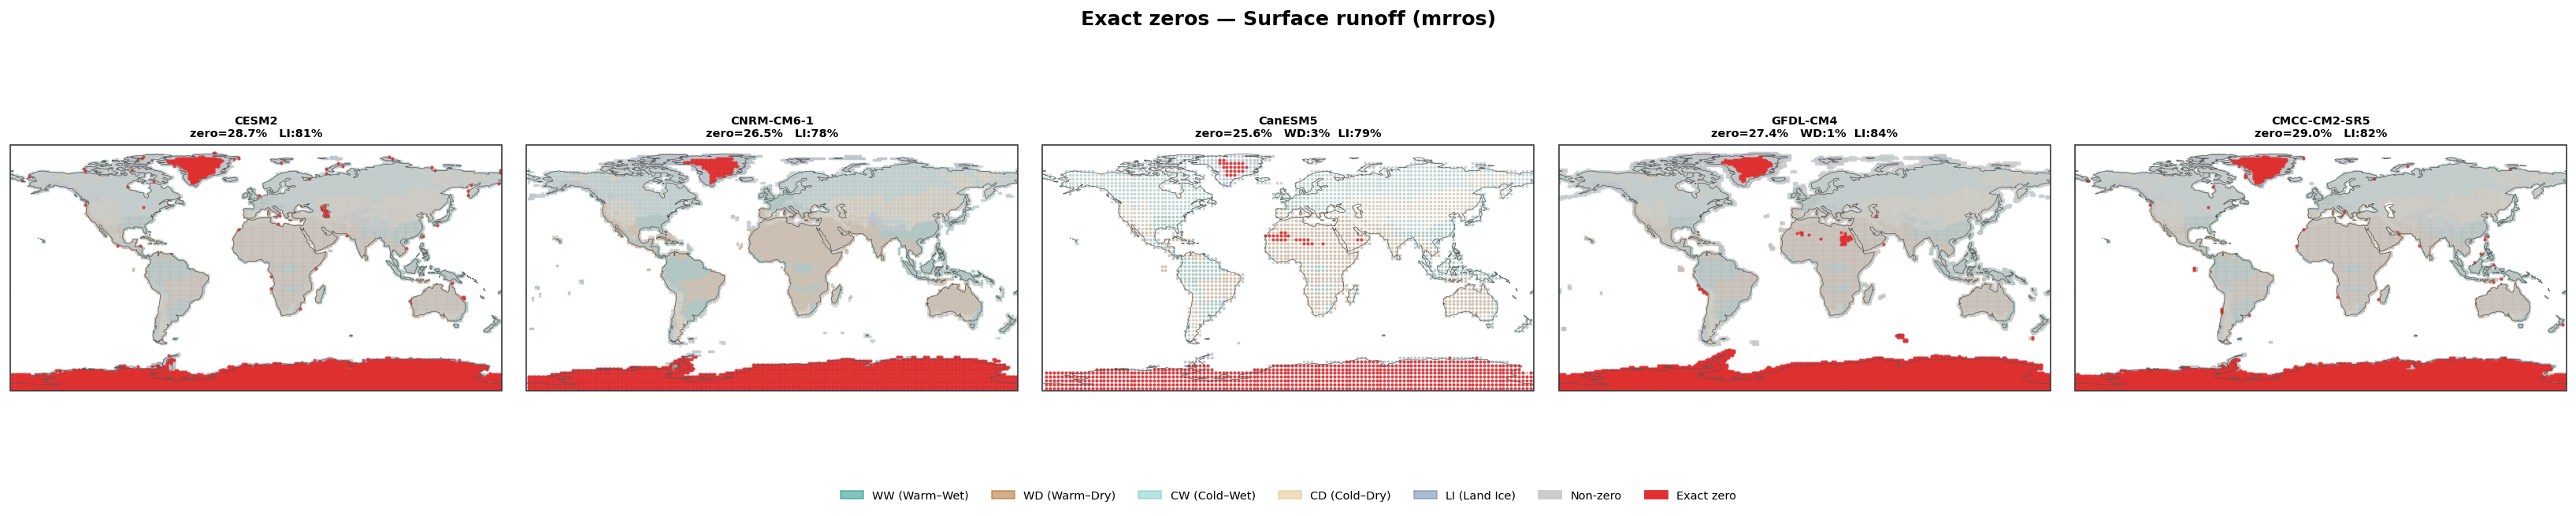

Saved: zero_map_prsn.png


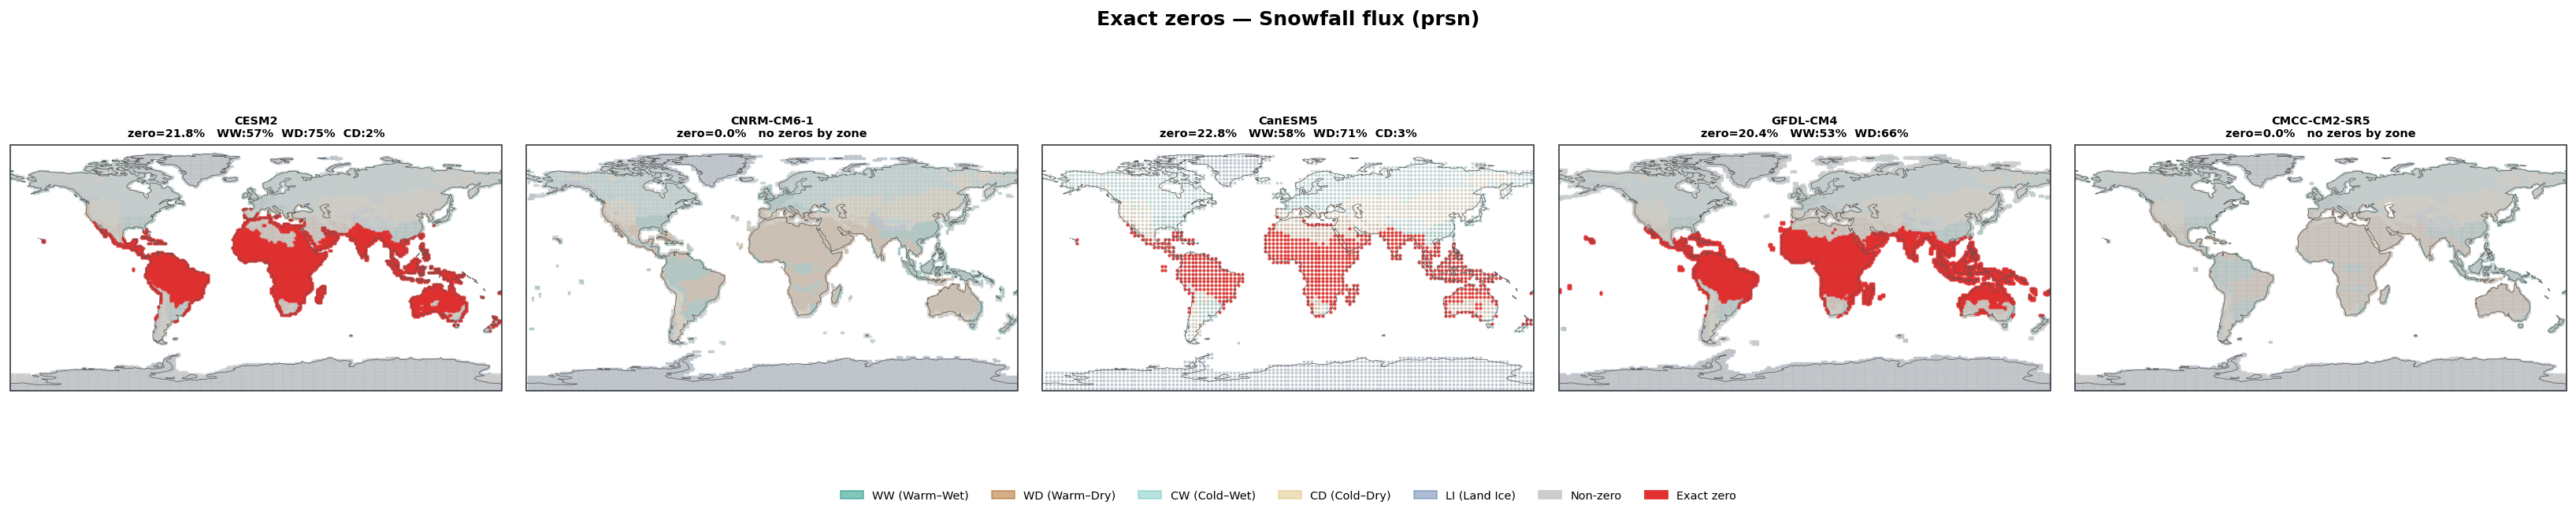

Saved: zero_map_tran.png


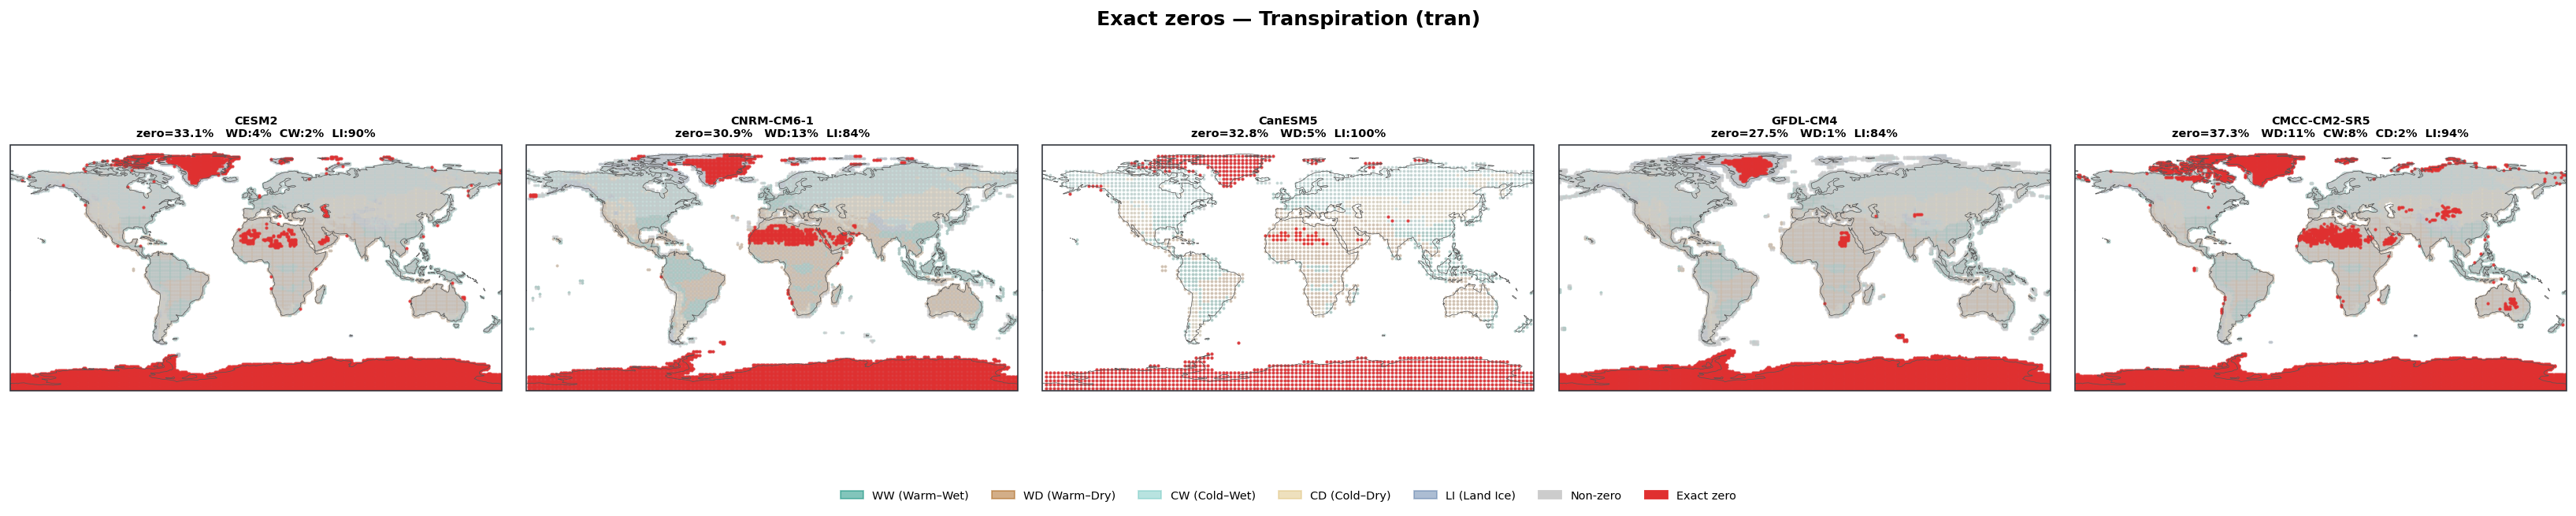

Saved: zero_map_lai.png


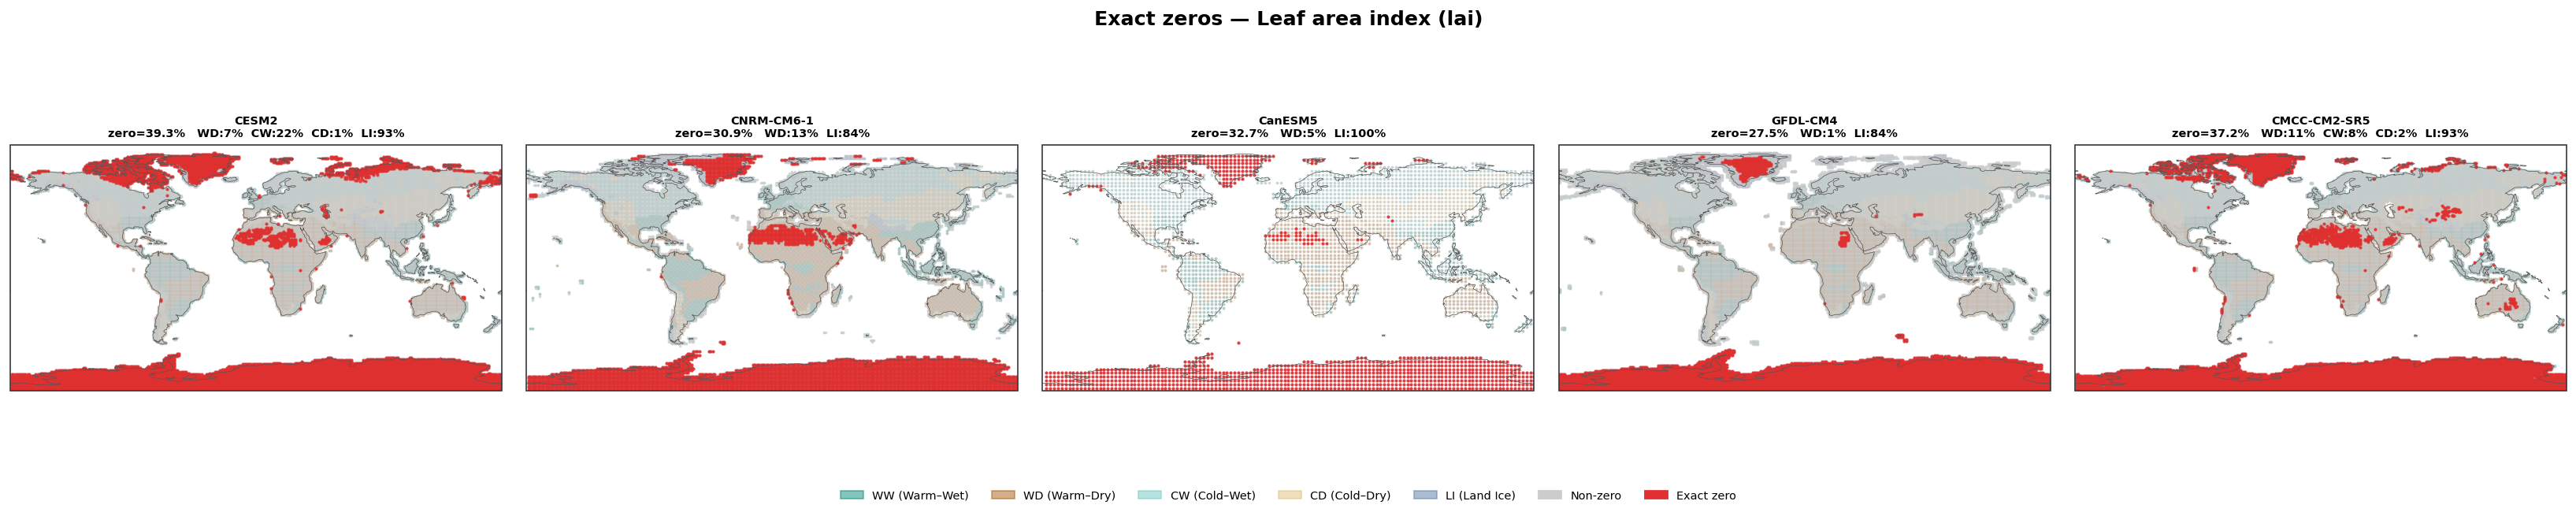

Saved: zero_map_evspsblsoi.png


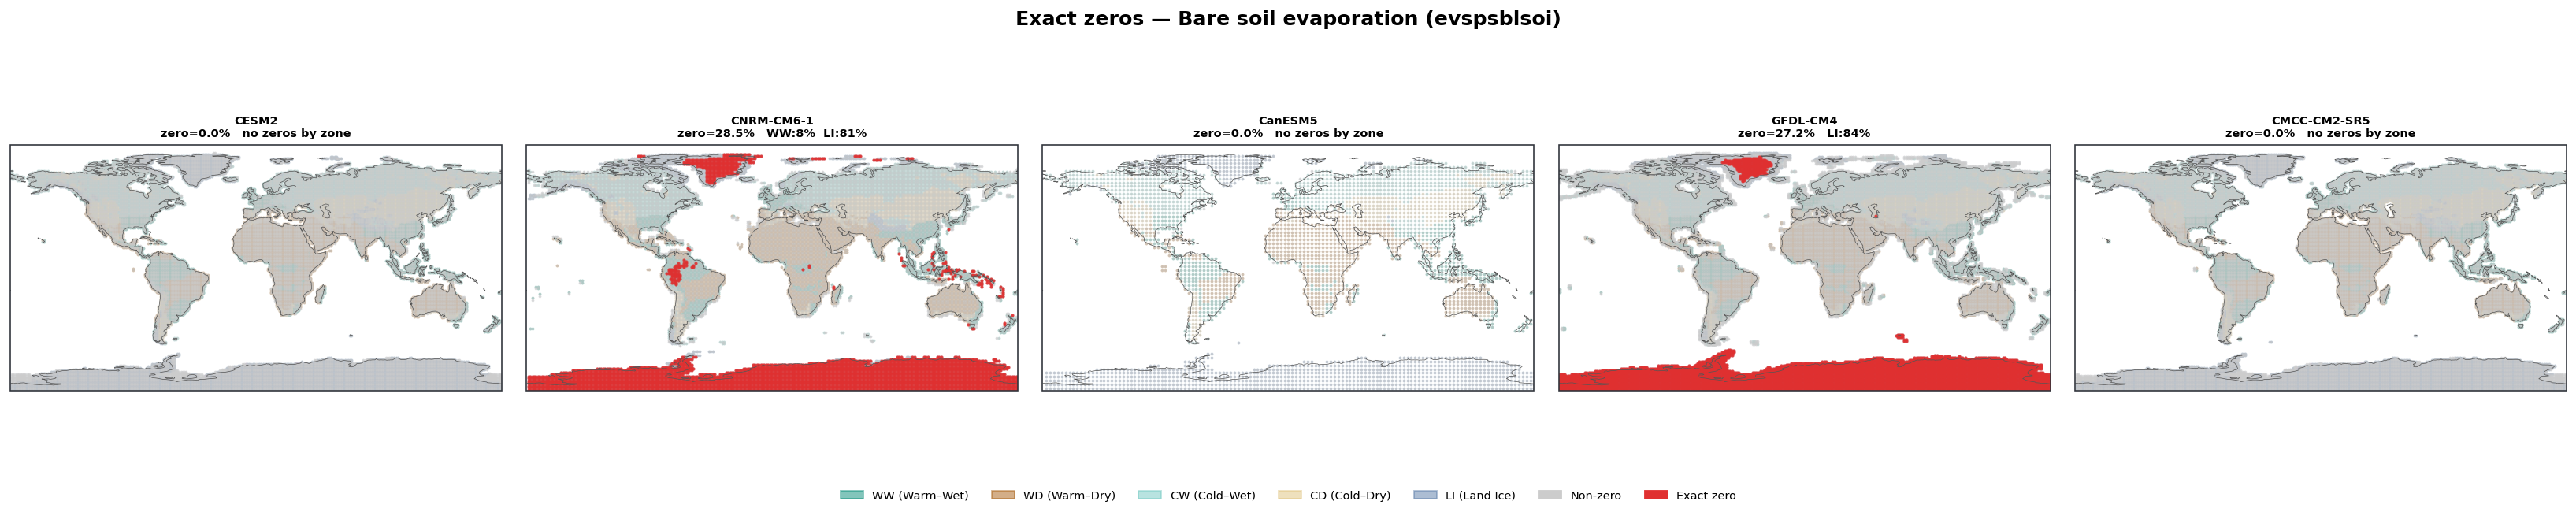

Saved: zero_map_mrso.png


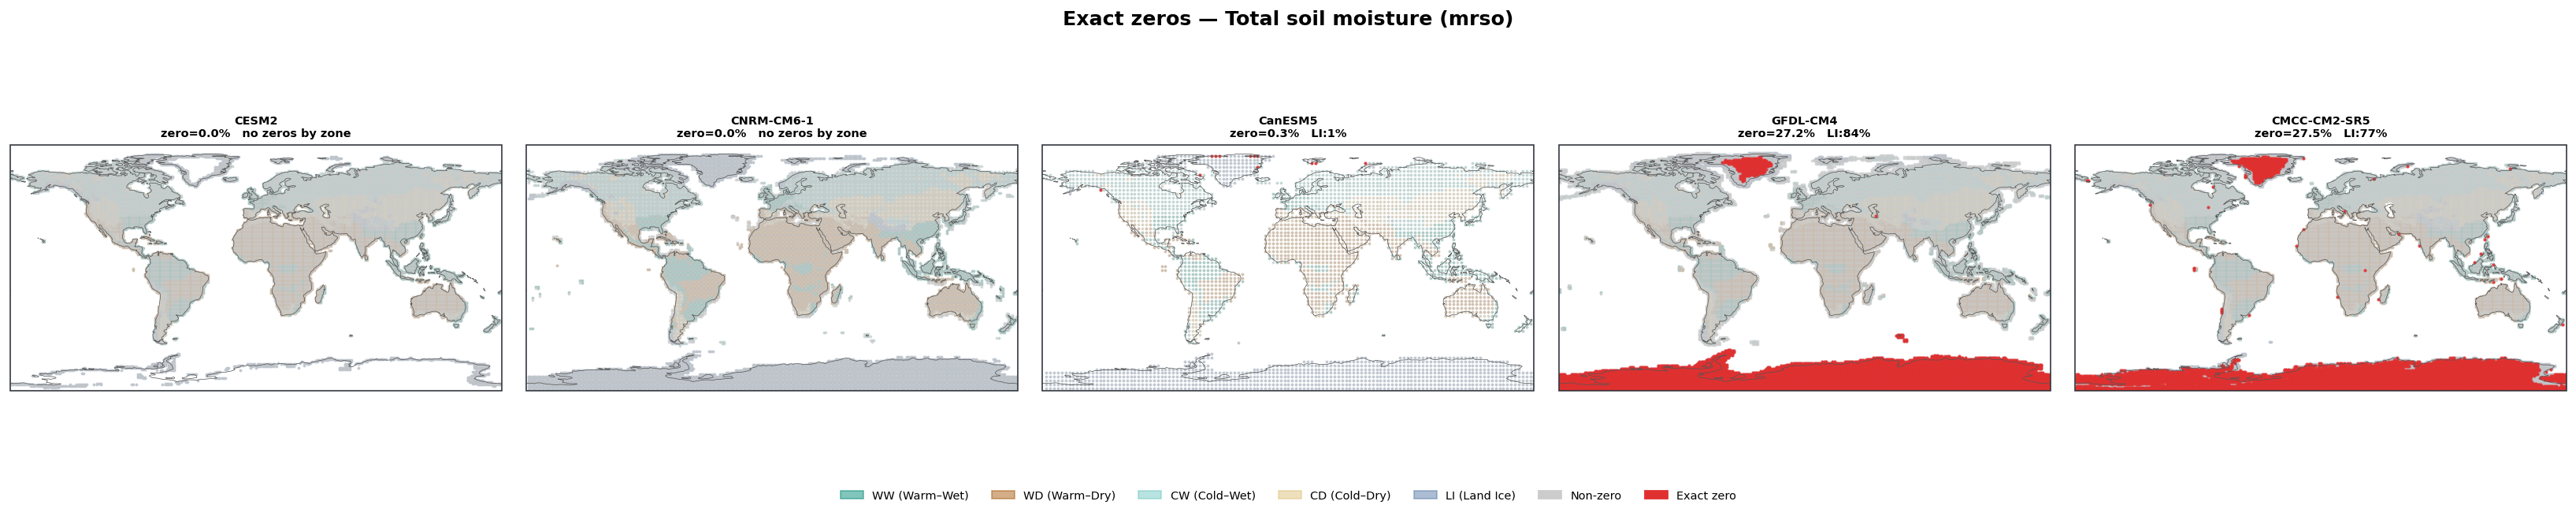

Saved: zero_map_mrsos.png


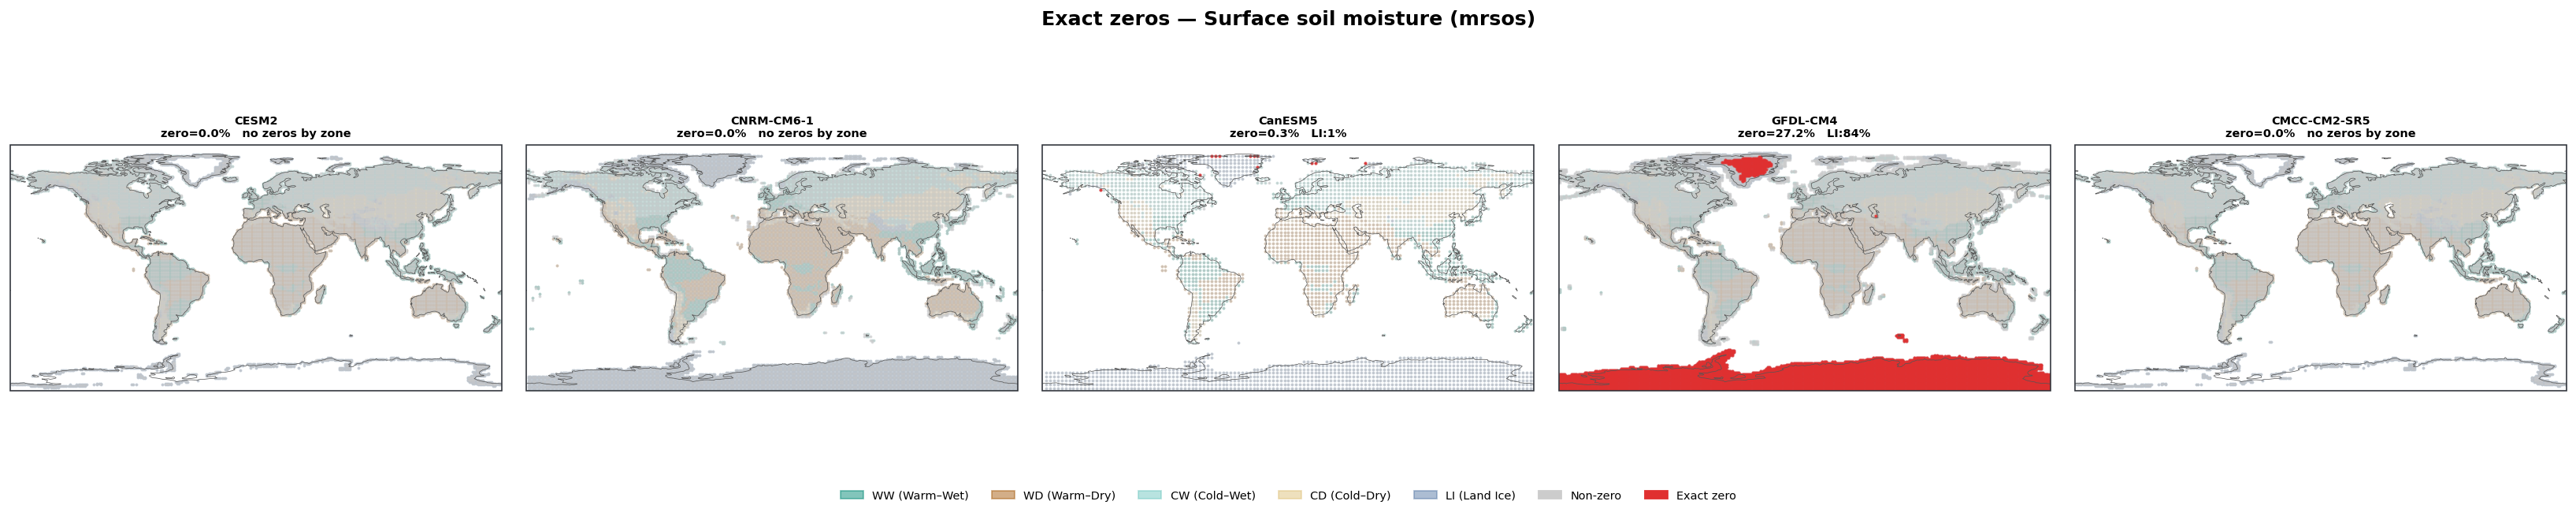

In [23]:
# --- Global maps: exact-zero spatial distribution per variable ---
# One figure per variable in ZERO_MAP_VARS, five subplots (one per model).
# Three layers: zone background → grey non-zero → red exact-zero.

import cartopy.feature as cfeature

OUTPUT_DIR = CASE_DIR / 'output' / 'S4.0'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for var in ZERO_MAP_VARS:
    fig, axes = plt.subplots(
        1, 5, figsize=(26, 5),
        subplot_kw={'projection': ccrs.PlateCarree()},
    )
    fig.subplots_adjust(wspace=0.05, top=0.88, bottom=0.05, left=0.02, right=0.98)

    for ax, run in zip(axes, runs):
        model = run['model']
        data = run['data']

        if var not in data.columns:
            ax.set_title(f'{model}\n(no {var})', fontsize=9)
            ax.set_global()
            ax.coastlines(linewidth=0.4, color='#888888')
            continue

        lon = data['lon'].values
        lat = data['lat'].values
        vals = data[var].values.astype(float)
        zones = data['analysis_zone'].values

        finite = np.isfinite(vals)
        lon_f, lat_f, vals_f, zones_f = lon[finite], lat[finite], vals[finite], zones[finite]

        is_zero = vals_f == 0.0
        n_total = len(vals_f)
        n_zero = is_zero.sum()
        pct_zero = 100 * n_zero / n_total if n_total > 0 else 0

        # Layer 1: zone background (all grid cells coloured by zone)
        for zone_name, zone_color in ZONE_COLORS.items():
            mask = zones_f == zone_name
            if mask.sum() == 0:
                continue
            ax.scatter(
                lon_f[mask], lat_f[mask],
                c=zone_color, s=1.2, alpha=0.35,
                transform=ccrs.PlateCarree(), rasterized=True,
            )

        # Layer 2: non-zero values in light grey
        non_zero_mask = ~is_zero
        if non_zero_mask.sum() > 0:
            ax.scatter(
                lon_f[non_zero_mask], lat_f[non_zero_mask],
                c='#CCCCCC', s=1.0, alpha=0.5,
                transform=ccrs.PlateCarree(), rasterized=True,
            )

        # Layer 3: exact zeros in red (top layer)
        if n_zero > 0:
            ax.scatter(
                lon_f[is_zero], lat_f[is_zero],
                c='#E03030', s=1.8, alpha=0.8,
                transform=ccrs.PlateCarree(), rasterized=True,
            )

        ax.set_global()
        ax.coastlines(linewidth=0.4, color='#555555')

        # Title: model name + global zero %
        zone_parts = []
        for zn in ['WW', 'WD', 'CW', 'CD', 'LI']:
            zmask = zones_f == zn
            if zmask.sum() > 0:
                zz = (vals_f[zmask] == 0.0).sum()
                zpct = 100 * zz / zmask.sum()
                if zpct > 0.5:
                    zone_parts.append(f'{zn}:{zpct:.0f}%')
        zone_str = '  '.join(zone_parts) if zone_parts else 'no zeros by zone'
        ax.set_title(f'{model}\nzero={pct_zero:.1f}%   {zone_str}', fontsize=8)

    fig.suptitle(
        f'Exact zeros — {ZERO_MAP_NAMES.get(var, var)}',
        fontsize=14, fontweight='semibold', y=0.97,
    )

    # Legend patches
    legend_handles = [
        mpatches.Patch(color=ZONE_COLORS[z], label=f'{z} ({ZONE_LABELS[z]})', alpha=0.5)
        for z in ['WW', 'WD', 'CW', 'CD', 'LI']
    ]
    legend_handles.append(mpatches.Patch(color='#CCCCCC', label='Non-zero'))
    legend_handles.append(mpatches.Patch(color='#E03030', label='Exact zero'))
    fig.legend(
        handles=legend_handles, loc='lower center',
        ncol=7, fontsize=8, frameon=False,
        bbox_to_anchor=(0.5, -0.01),
    )

    out_path = OUTPUT_DIR / f'zero_map_{var}.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f'Saved: {out_path.name}')
    plt.show()